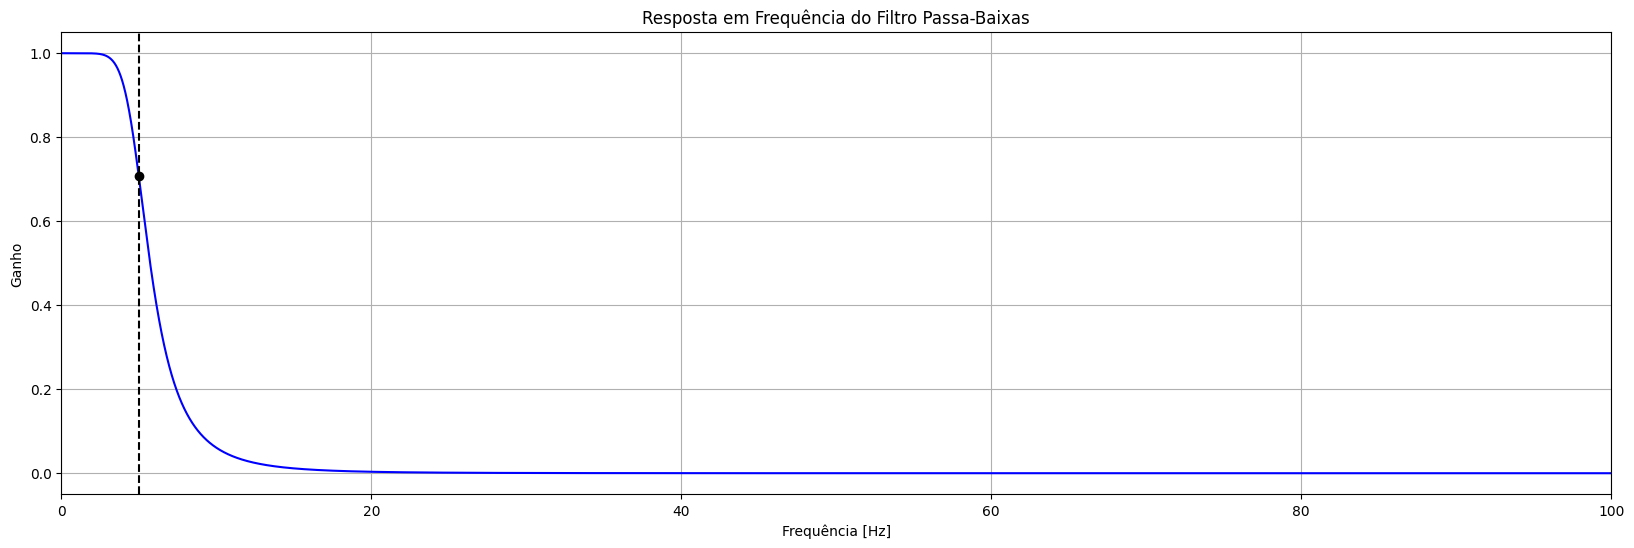

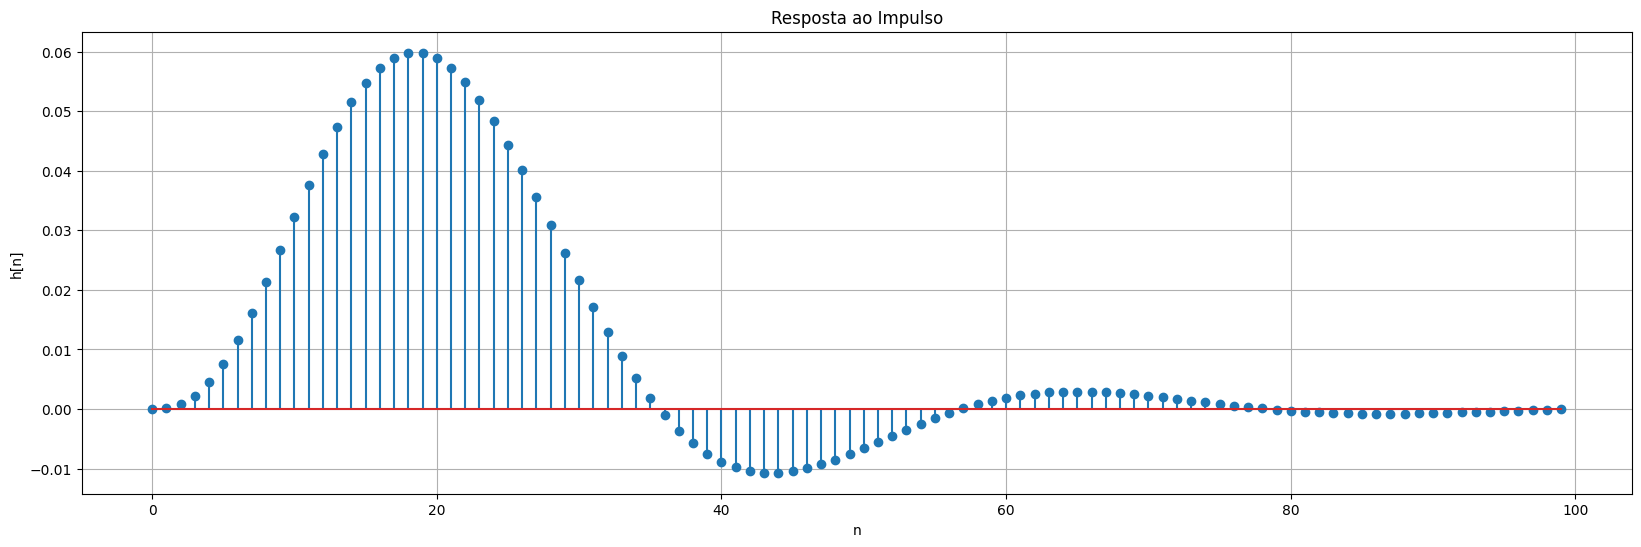

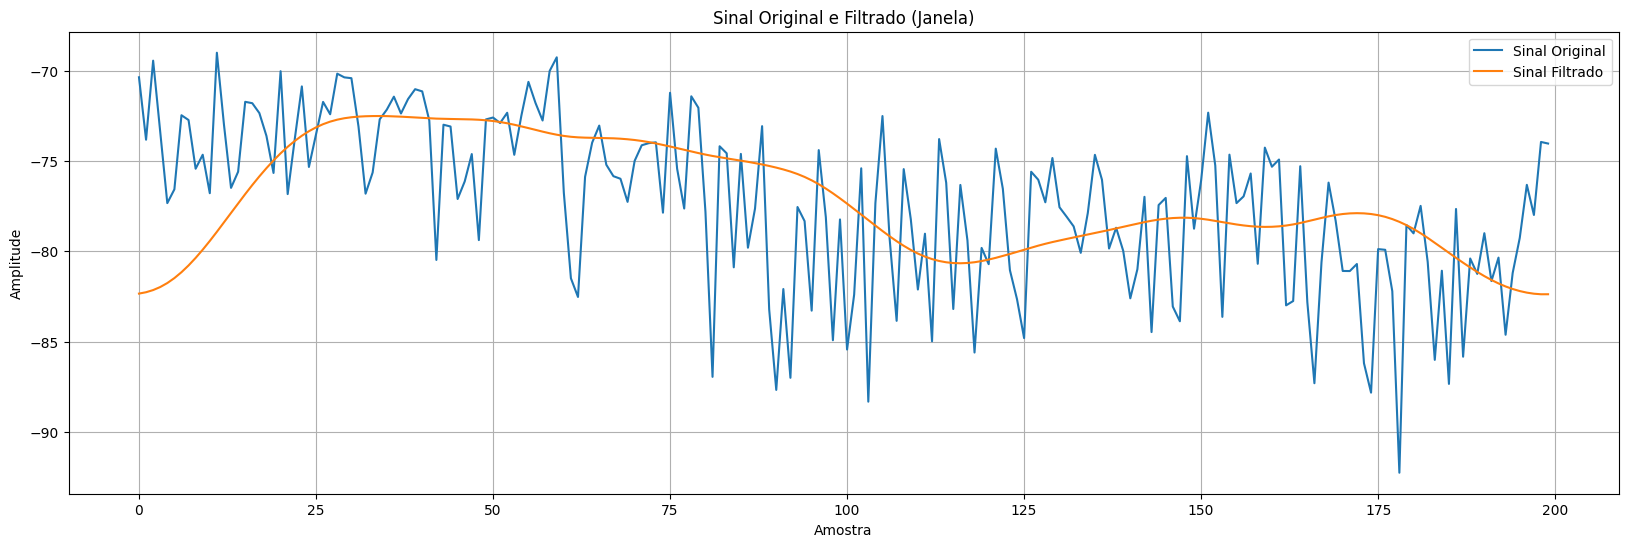

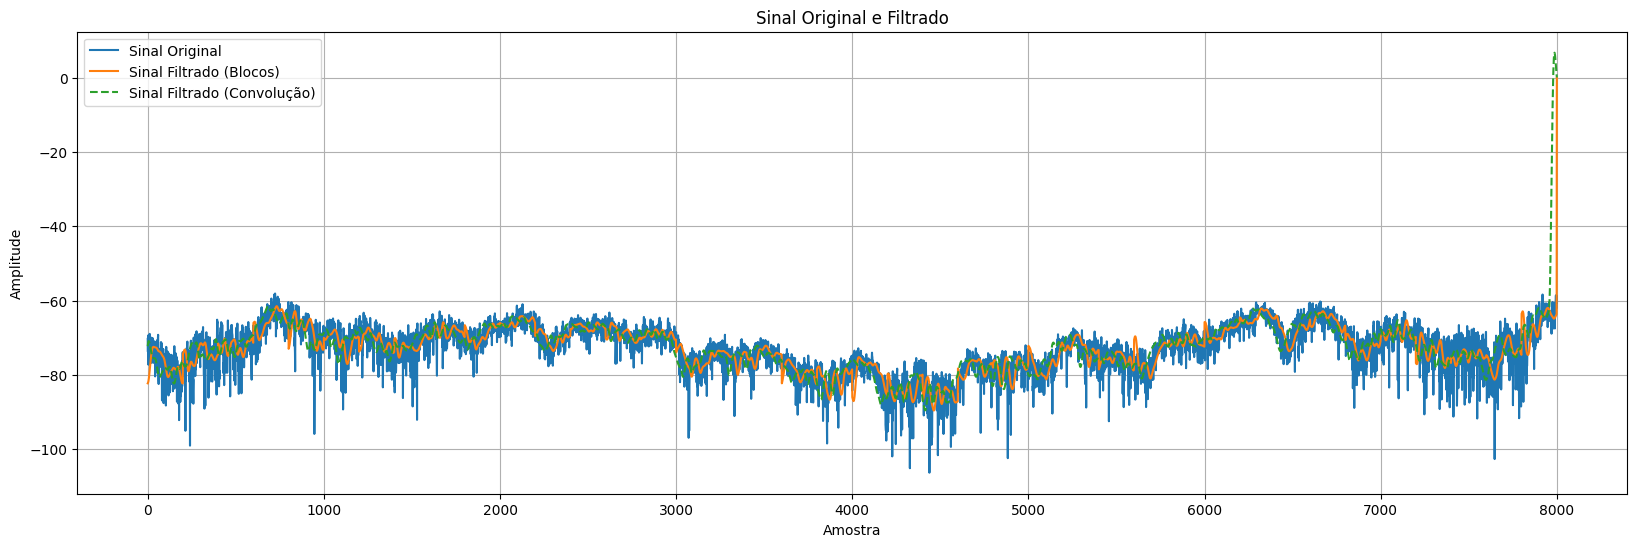

In [1]:
import numpy as np
from scipy.signal import butter, freqz, lfilter
import matplotlib.pyplot as plt

# Taxa de amostragem e frequência de corte desejada
fs = 200.0
cutoff = 5.0

# Projeto do filtro passa-baixas Butterworth
ordem = 4  # Ordem do filtro
nyquist = 0.5 * fs
frequencia_normalizada = cutoff / nyquist
b, a = butter(ordem, frequencia_normalizada, btype='low', analog=False)

# Resposta em frequência
plt.figure(figsize=(20, 6))
w, h = freqz(b, a, worN=8000)
plt.plot(0.5 * fs * w / np.pi, np.abs(h), 'b')
plt.plot(cutoff, 0.5 * np.sqrt(2), 'ko')
plt.axvline(cutoff, color='k', linestyle='--')
plt.xlim(0, 0.5 * fs)
plt.title("Resposta em Frequência do Filtro Passa-Baixas")
plt.xlabel('Frequência [Hz]')
plt.ylabel('Ganho')
plt.grid()
plt.show()

# Resposta ao impulso
plt.figure(figsize=(20, 6))
impulso = np.zeros(100)
impulso[0] = 1  # Função delta
h = lfilter(b, a, impulso)
plt.stem(h)
plt.title('Resposta ao Impulso')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

# Carregar o sinal
sinal = np.loadtxt('potencia.txt')

# Selecionar uma janela de N amostras (1 segundo)
N = 200
janela = sinal[:N]

# Aplicar o filtro no domínio da DFT
janela_fft = np.fft.fft(janela)
h_fft = np.fft.fft(h, N)
janela_filtrada_fft = janela_fft * h_fft
janela_filtrada = np.fft.ifft(janela_filtrada_fft).real

plt.figure(figsize=(20, 6))
plt.plot(janela, label='Sinal Original')
plt.plot(janela_filtrada, label='Sinal Filtrado')
plt.legend()
plt.title('Sinal Original e Filtrado (Janela)')
plt.xlabel('Amostra')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Processar o sinal completo em blocos de N amostras
def filtrar_sinal_em_blocos(sinal, b, a, N):
    sinal_filtrado = np.zeros_like(sinal)
    for i in range(0, len(sinal), N):
        bloco = sinal[i:i+N]
        if len(bloco) < N:
            break
        bloco_fft = np.fft.fft(bloco)
        bloco_filtrado_fft = bloco_fft * h_fft
        bloco_filtrado = np.fft.ifft(bloco_filtrado_fft).real
        sinal_filtrado[i:i+N] = bloco_filtrado
    return sinal_filtrado

sinal_filtrado = filtrar_sinal_em_blocos(sinal, b, a, N)

# Comparar com a convolução
sinal_conv = np.convolve(sinal, h, mode='same')

plt.figure(figsize=(20, 6))
plt.plot(sinal, label='Sinal Original')
plt.plot(sinal_filtrado, label='Sinal Filtrado (Blocos)')
plt.plot(sinal_conv, label='Sinal Filtrado (Convolução)', linestyle='dashed')
plt.legend()
plt.title('Sinal Original e Filtrado')
plt.xlabel('Amostra')
plt.ylabel('Amplitude')
plt.grid()
plt.show()
